# Mission 5

# **TASK 3**

 **Selected two Agile values, one Agile practice, and one Design Thinking practice:

 Agile Value:

 1. **Individuals and Interactions Over Processes and Tools.** We applied this by communicating regularly as a team, using Daily Stand Ups to discuss progress, challenges, and support needed. This helped the team avoid confusion and work together more effectively.

 2. **Responding to Change Over Following a Plan**. We applied this by staying flexible during the project. If we found issues with the dataset, model performance, or task priorities, we discussed them as a team and updated our Jira board when needed.

 Agile Practice:

 **Sprint Planning**. We used this practice to identify the main tasks for the mission, assign responsibilities, and organise the work in Jira. This helped the team understand what needed to be completed and track progress.

 Design Thinking practice:

 **Define the Problem**. We applied this by discussing the goal of the predictive analytics project before building the models. This helped us understand the purpose of the analysis, identify the target variable, and make sure the model focused on solving the correct problem.


# **TASK 4**

In [1]:
# Install Azure Blob Storage 
%pip install azure-storage-blob

# Import required libraries
from azure.storage.blob import BlobServiceClient
import pandas as pd
from io import StringIO

# Azure Blob Storage credentials
connect_str = "<YOUR_CONNECTION_STRING>"

container_name = "businesscases"
blob_name = "Final_Mission_loan_data.csv"

# Create the BlobServiceClient
blob_service_client = BlobServiceClient.from_connection_string(connect_str)

# Access the container
container_client = blob_service_client.get_container_client(container_name)

# Access the blob file
blob_client = container_client.get_blob_client(blob_name)

# Download the blob content
blob_data = blob_client.download_blob().readall()

# Convert the downloaded data into a pandas DataFrame
csv_data = blob_data.decode("utf-8")
df_loan = pd.read_csv(StringIO(csv_data))

# Display the first few rows
df_loan.head()

Note: you may need to restart the kernel to use updated packages.


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1


# **TASK 5**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_loan.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1


In [3]:
# Check the shape of the dataset
df_loan.shape

(45000, 14)

In [4]:
# Check column names and data types
df_loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  int64  
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  int64  
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  int64  
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  int64  
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [5]:
# Check missing values in each column
df_loan.isnull().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

In [6]:
# Check percentage of missing values
(df_loan.isnull().sum() / len(df_loan)) * 100

person_age                        0.0
person_gender                     0.0
person_education                  0.0
person_income                     0.0
person_emp_exp                    0.0
person_home_ownership             0.0
loan_amnt                         0.0
loan_intent                       0.0
loan_int_rate                     0.0
loan_percent_income               0.0
cb_person_cred_hist_length        0.0
credit_score                      0.0
previous_loan_defaults_on_file    0.0
loan_status                       0.0
dtype: float64

In [7]:
# Summary statistics for numerical columns
df_loan.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


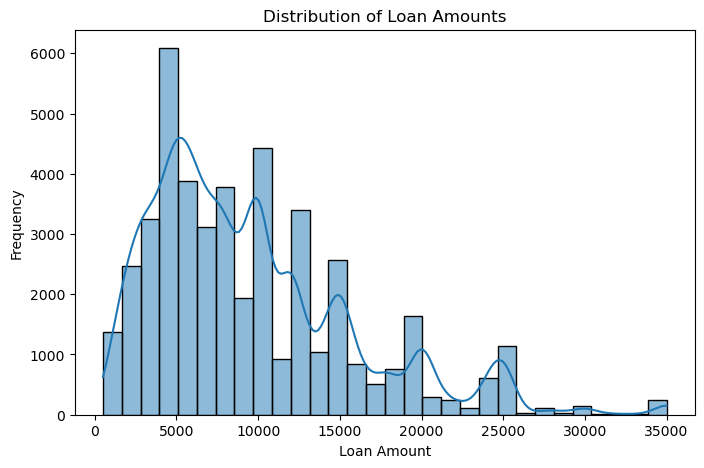

In [8]:
# Distribution of loan amounts
plt.figure(figsize=(8, 5))
sns.histplot(df_loan['loan_amnt'], bins=30, kde=True)
plt.title('Distribution of Loan Amounts')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')
plt.show()

Most loan amounts are concentrated between $3,000 and $15,000, with the highest frequency around $5,000.
There are fewer loans with very high amounts, especially above $20,000, which means the distribution is right-skewed. This suggests that most applicants request smaller to medium-sized loans, while only a small number apply for larger loans.

In [9]:
# Display all column names
df_loan.columns

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file', 'loan_status'],
      dtype='object')

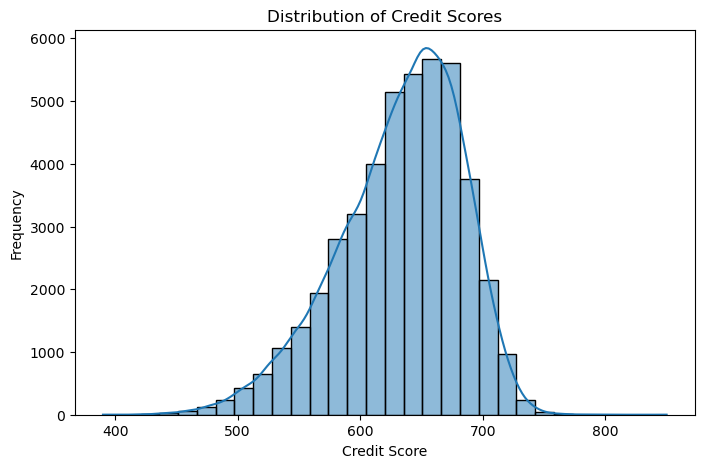

In [10]:
# Distribution of credit scores
plt.figure(figsize=(8, 5))
sns.histplot(df_loan['credit_score'], bins=30, kde=True)
plt.title('Distribution of Credit Scores')
plt.xlabel('Credit Score')
plt.ylabel('Frequency')
plt.show()

Most credit scores are concentrated between 600 and 700, with the highest frequency around 650 to 670.
The distribution looks close to a normal bell shape, meaning most applicants have medium-range credit scores. Very low scores below 500 and very high scores above 750 are less common in the dataset.

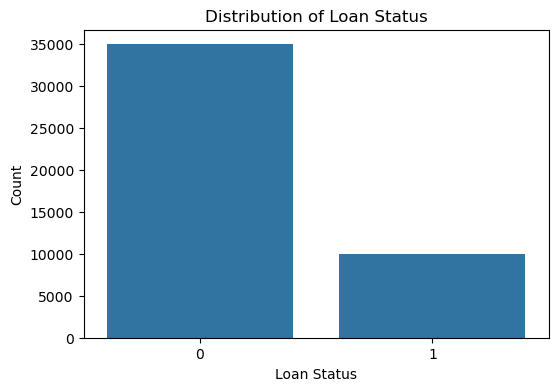

In [11]:
# Distribution of loan status
plt.figure(figsize=(6, 4))
sns.countplot(x='loan_status', data=df_loan)
plt.title('Distribution of Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()

Most loans have a status of 0, with around 35,000 records, while status 1 has around 10,000 records.
This means the dataset is imbalanced, because there are many more loans in class 0 than class 1. This is important for modelling because the model may become better at predicting the majority class and less accurate at predicting the minority class.

In [12]:
# Select only numerical columns
numeric_df = df_loan.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
correlation_matrix = numeric_df.corr()

# Display the correlation matrix
correlation_matrix

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
person_age,1.000000,0.193698,0.954412,0.050750,0.013402,-0.043299,0.861985,0.178432,-0.021476
person_income,0.193698,1.000000,0.185987,0.242290,0.001510,-0.234177,0.124316,0.035919,-0.135808
person_emp_exp,0.954412,0.185987,1.000000,0.044589,0.016631,-0.039862,0.824272,0.186196,-0.020481
loan_amnt,0.050750,0.242290,0.044589,1.000000,0.146093,0.593011,0.042969,0.009074,0.107714
loan_int_rate,0.013402,0.001510,0.016631,0.146093,1.000000,0.125209,0.018008,0.011498,0.332005
loan_percent_income,-0.043299,-0.234177,-0.039862,0.593011,0.125209,1.000000,-0.031868,-0.011483,0.384880
cb_person_cred_hist_length,0.861985,0.124316,0.824272,0.042969,0.018008,-0.031868,1.000000,0.155204,-0.014851
credit_score,0.178432,0.035919,0.186196,0.009074,0.011498,-0.011483,0.155204,1.000000,-0.007647
loan_status,-0.021476,-0.135808,-0.020481,0.107714,0.332005,0.384880,-0.014851,-0.007647,1.000000


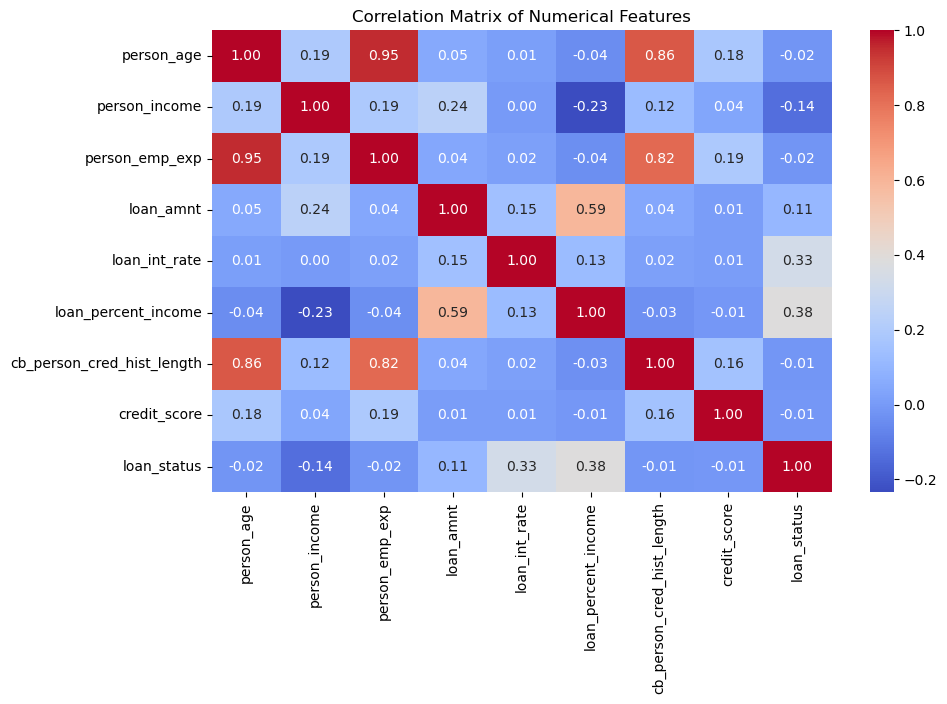

In [13]:
# Visualise correlation matrix using heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

The heatmap shows that loan_status has the strongest positive correlation with:
loan_percent_income: 0.38
loan_int_rate: 0.33
loan_amnt: 0.11
This suggests that loans are more likely to have status 1 when the loan uses a higher percentage of the person’s income, has a higher interest rate, or has a larger loan amount.
The chart also shows strong relationships between some features, such as person_age and person_emp_exp at 0.95, which makes sense because employment experience usually increases with age.

In [14]:
# Correlation of numerical variables with loan_status
numeric_df.corr()['loan_status'].sort_values(ascending=False)

loan_status                   1.000000
loan_percent_income           0.384880
loan_int_rate                 0.332005
loan_amnt                     0.107714
credit_score                 -0.007647
cb_person_cred_hist_length   -0.014851
person_emp_exp               -0.020481
person_age                   -0.021476
person_income                -0.135808
Name: loan_status, dtype: float64

In [15]:
# Make a copy of the dataset
df_eda = df_loan.copy()

# Check column names first
df_eda.columns

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file', 'loan_status'],
      dtype='object')

In [16]:
# Create loan_status_encoded only if loan_status exists
if 'loan_status' in df_eda.columns:
    if df_eda['loan_status'].dtype == 'object':
        df_eda['loan_status_encoded'] = df_eda['loan_status'].astype('category').cat.codes
    else:
        df_eda['loan_status_encoded'] = df_eda['loan_status']
else:
    print("loan_status column not found. Please check the column names.")

In [17]:
df_eda[['loan_status', 'loan_status_encoded']].head()

,loan_status,loan_status_encoded
0,1,1
1,0,0
2,1,1
3,1,1
4,1,1


In [18]:
# Select numerical columns
numeric_df_encoded = df_eda.select_dtypes(include=['int64', 'float64'])

# Correlation with target variable
target_correlation = numeric_df_encoded.corr()['loan_status_encoded'].sort_values(ascending=False)

target_correlation

loan_status                   1.000000
loan_status_encoded           1.000000
loan_percent_income           0.384880
loan_int_rate                 0.332005
loan_amnt                     0.107714
credit_score                 -0.007647
cb_person_cred_hist_length   -0.014851
person_emp_exp               -0.020481
person_age                   -0.021476
person_income                -0.135808
Name: loan_status_encoded, dtype: float64

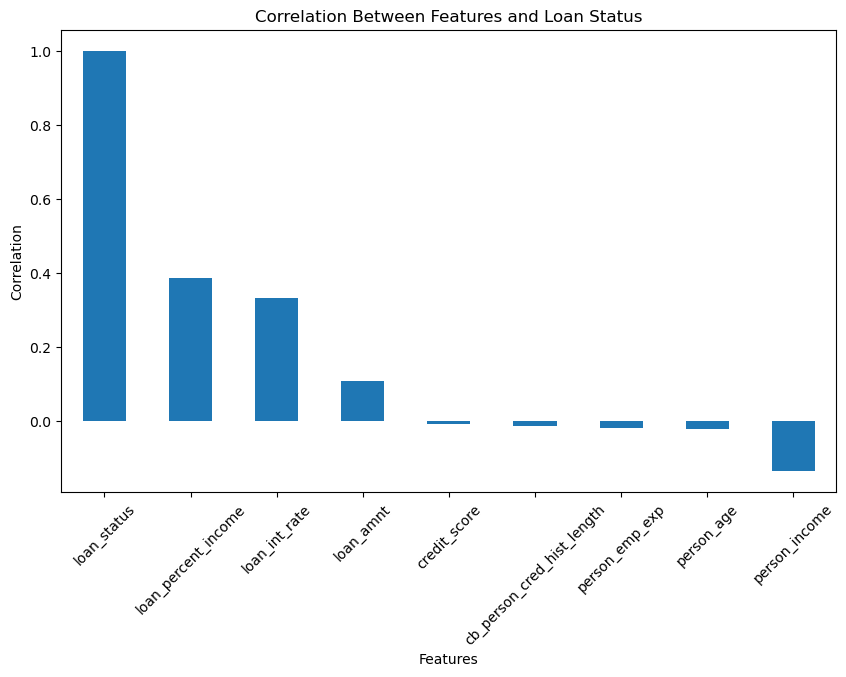

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
target_correlation.drop('loan_status_encoded').plot(kind='bar')
plt.title('Correlation Between Features and Loan Status')
plt.xlabel('Features')
plt.ylabel('Correlation')
plt.xticks(rotation=45)
plt.show()

loan_percent_income has the strongest relationship with loan_status, followed by loan_int_rate.
This suggests that applicants are more likely to have loan status 1 when the loan takes up a higher percentage of their income or when the interest rate is higher.
Other features, such as credit_score, credit history length, employment experience, and age, have very weak correlation with loan status.

# **TASK 6**

In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Splitting data into features (X) and target (y)
X = df_loan.drop(columns=['loan_status'])
y = df_loan['loan_status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Handling missing values 
X_train = X_train.fillna(X_train.mode().iloc[0])
X_test = X_test.fillna(X_train.mode().iloc[0])

# Defining the categorical columns to encode
categorical_cols = ['person_gender', 'person_education', 'person_home_ownership']

# Encoding categorical columns
for col in categorical_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))

# Align columns to ensure train and test sets match exactly
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [21]:
X_train

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file
25180,34,0,1,97265,11,0,15000,PERSONAL,12.73,0.15,9,631,No
12555,25,1,3,72953,3,3,12000,VENTURE,11.86,0.16,4,659,Yes
29153,41,0,4,322597,18,0,24000,PERSONAL,10.37,0.07,11,683,Yes
23838,27,1,0,94232,4,3,9600,EDUCATION,17.14,0.10,7,641,No
35686,27,1,4,84873,7,3,7059,HOMEIMPROVEMENT,12.97,0.08,3,706,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,26,1,3,88451,6,0,10625,EDUCATION,6.03,0.12,4,559,Yes
44732,25,0,3,34772,3,0,5876,HOMEIMPROVEMENT,11.69,0.17,4,647,No
38158,33,0,0,58317,9,0,10707,VENTURE,10.74,0.18,9,652,Yes
860,26,1,4,178602,6,3,20000,DEBTCONSOLIDATION,17.99,0.11,3,604,No


In [22]:
y_train

25180    0
12555    0
29153    0
23838    0
35686    0
        ..
11284    0
44732    1
38158    0
860      1
15795    0
Name: loan_status, Length: 36000, dtype: int64

In [23]:
X_test

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file
37979,32,1,0,96865,10,0,7500,EDUCATION,6.04,0.08,10,601,No
9911,24,1,0,56838,6,3,9000,EDUCATION,11.49,0.16,4,647,Yes
43386,22,0,4,37298,0,3,5000,MEDICAL,14.88,0.13,4,711,No
13822,23,0,1,39944,1,2,5000,VENTURE,13.99,0.13,3,597,Yes
44810,42,1,3,67974,20,0,10000,HOMEIMPROVEMENT,15.41,0.15,11,586,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14572,21,1,1,133205,0,0,14000,VENTURE,9.99,0.11,2,654,No
30384,39,1,3,61889,17,3,6725,EDUCATION,16.45,0.11,11,606,Yes
36665,24,0,4,78950,1,3,14000,EDUCATION,11.65,0.18,3,614,No
30569,38,1,0,37142,16,3,8000,MEDICAL,11.01,0.22,14,695,No


By keeping the data more simple, I have used the Label encoding across all three of the categorical columns: 
<mark>a.)</mark> person_gender:  Female 0;  and  Male 1
<mark>b.) </mark>person_education:  Bachelor 0;  High School 1;   Master 2
<mark>c.) </mark>person_home_ownership:  Mortgage 0;  Own 1;  Rent 2

# **TASK 7**

#### **Logistic Regression**

In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Loading data and split features
X = df_loan.drop(columns=['loan_status'])
y = df_loan['loan_status']

# Split into 80% Training and 20% Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Handling Missing Values
# Fill missing categorical spots with the most common value 
cat_cols_temp = X_train.select_dtypes(include=['object', 'category']).columns
for col in cat_cols_temp:
    mode_val = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(mode_val)
    X_test[col] = X_test[col].fillna(mode_val)

# Fill missing numerical spots with the median
num_cols_temp = X_train.select_dtypes(include=['number']).columns
for col in num_cols_temp:
    median_val = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_val)
    X_test[col] = X_test[col].fillna(median_val)


# Label Encoding

categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

for col in categorical_cols:
    le = LabelEncoder()

    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))


# Scaling (incomes, ages, and your new label codes) 
# Logistic Regression  process them mathematically.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# rain Logistic Regression
log_reg_model = LogisticRegression(random_state=42)
log_reg_model.fit(X_train_scaled, y_train)


# Predict and Evaluate
y_pred_log_reg = log_reg_model.predict(X_test_scaled)

# Calculate and print accuracy
log_reg_accuracy = accuracy_score(y_test, y_pred_log_reg)
print(f"Logistic Regression Accuracy: {log_reg_accuracy:.2%}\n")

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred_log_reg)
print(cm)



Logistic Regression Accuracy: 89.01%

Confusion Matrix:
[[6542  448]
 [ 541 1469]]


An 89.01% Logistic Regression accuracy is a very strong starting point for a loan default model.



Confusion Matrix shows you the exact count of the model guessed right vs. where it guessed wrong.

6,542 True Negatives: Good loans (0) the model correctly predicted as Good.

1,469 True Positives: Defaulted loans (1) that the model correctly predicted as Defaults.

448 False Positives: Good loans: The model accidentally labeled as Defaults (Potential lost revenue from turning away good clients).

541 False Negatives:  This is the biggest risk. These are people who actually defaulted (1), but the model approved them as Good (0). These represent lost money for the lender.

Conclusion
The Logistic Regression model predicts whether a person will pay back their loan or fail to pay it back (default). The overall accuracy is 89.01% . 

The Good News: The model is incredibly smart at recognizing safe borrowers. It correctly spots them 94% of the time.

The Risk: It only catches 73% of the people who will actually default. This means 541 risky borrowers slipped through the cracks and were accidentally approved.

Finally,The model is a highly successful starting point. However, because approving a bad loan is very expensive for a bank, the next step should focus on tuning the model to better catch those hidden defaults before it is used in the real world.


#### **Random Forest Classifier**

Train a Random Forest Regression model with 100 Estimators

In [25]:
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Predict on the test seet
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"random Forest Accuracy: {rf_accuracy:.2%}\n")

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=[0, 1])
cm_rf_df = pd.DataFrame(cm_rf,
                     index=["Actual: 0 (Negative)", "Actual: 1 (Positive)"],
                     columns=["Predicted: 0 (Negative)", "Predicted: 1 (Positive)"])

print(cm_rf_df)

random Forest Accuracy: 92.87%

                      Predicted: 0 (Negative)  Predicted: 1 (Positive)
Actual: 0 (Negative)                     6797                      193
Actual: 1 (Positive)                      449                     1561


The Random Forest Classifier with 100 estimators has 92.87% accuracy of making correct predictions.

From the confusion matrix, there are 6797 True Negatives which correctly predicted as loan approved (0), 1561 True Positives which correctly predicted as defaulted loan (1), 193 False Positive which wrongly predicted as defaulted loan (1) and 449 False Negatives which wrongly predicted as loan approved (0).

 

Adjust the Random Forest parameters to 150 Estimators and train again

In [26]:
## Tune the model with 150 Estimators

# Initialize Random Forest Model with the adjusted parameters - 150 Estimators
rf_model_tuned_150 = RandomForestClassifier(n_estimators=150, random_state=42)

# Train the model
rf_model_tuned_150.fit(X_train, y_train)

# Predict on the test seet
y_pred_rf_tuned_150 = rf_model_tuned_150.predict(X_test)

# Evaluate the model
rf_accuracy_tuned_150 = accuracy_score(y_test, y_pred_rf_tuned_150)
print(f"random Forest (150 Estimators) Accuracy: {rf_accuracy_tuned_150:.2%}\n")

# Confusion Matrix
cm_rf_tuned_150 = confusion_matrix(y_test, y_pred_rf_tuned_150, labels=[0, 1])
cm_rf_tuned_150 = pd.DataFrame(cm_rf_tuned_150,
                     index=["Actual: 0 (Negative)", "Actual: 1 (Positive)"],
                     columns=["Predicted: 0 (Negative)", "Predicted: 1 (Positive)"])

print(cm_rf_tuned_150)

random Forest (150 Estimators) Accuracy: 92.79%

                      Predicted: 0 (Negative)  Predicted: 1 (Positive)
Actual: 0 (Negative)                     6794                      196
Actual: 1 (Positive)                      453                     1557


The Random Forest Classifier with 150 estimators has 92.79% accuracy of making correct predictions.

From the confusion matrix, there are 6794 True Negatives which correctly predicted as loan approved (0), 1557 True Positives which correctly predicted as defaulted loan (1), 196 False Positive which wrongly predicted as defaulted loan (1) and 453 False Negatives which wrongly predicted as loan approved (0).

Adjust the Random Forest parameters to 300 Estimators and train again

In [27]:
## Tune the model with 300 Estimators

# Initialize Random Forest Model with the adjusted parameters - 300 Estimators
rf_model_tuned_300 = RandomForestClassifier(n_estimators=300, random_state=42)

# Train the model
rf_model_tuned_300.fit(X_train, y_train)

# Predict on the test seet
y_pred_rf_tuned_300 = rf_model_tuned_300.predict(X_test)

# Evaluate the model
rf_accuracy_tuned_300 = accuracy_score(y_test, y_pred_rf_tuned_300)
print(f"Random Forest (300 Estimators) Accuracy: {rf_accuracy_tuned_300:.2%}\n")

# Confusion Matrix
cm_rf_tuned_300 = confusion_matrix(y_test, y_pred_rf_tuned_300, labels=[0, 1])
cm_rf_tuned_300 = pd.DataFrame(cm_rf_tuned_300,
                     index=["Actual: 0 (Negative)", "Actual: 1 (Positive)"],
                     columns=["Predicted: 0 (Negative)", "Predicted: 1 (Positive)"])

print(cm_rf_tuned_300)

Random Forest (300 Estimators) Accuracy: 92.70%

                      Predicted: 0 (Negative)  Predicted: 1 (Positive)
Actual: 0 (Negative)                     6785                      205
Actual: 1 (Positive)                      452                     1558


The Random Forest Classifier with 300 estimators has 92.70% accuracy of making correct predictions.

From the confusion matrix, there are 6785 True Negatives which correctly predicted as loan approved (0), 1558 True Positives which correctly predicted as defaulted loan (1), 205 False Positive which wrongly predicted as defaulted loan (1) and 452 False Negatives which wrongly predicted as loan approved (0).

In [28]:
# Create a table in descending order to compare accuracy score of Random Forest with different number of Estimators
rf_accuracy_table = pd.DataFrame([rf_accuracy, rf_accuracy_tuned_150, rf_accuracy_tuned_300],
                        columns=["Accuracy Score"],
                        index=["100 Estimators", "150 Estimators", "300 Estimators"])
print(rf_accuracy_table.sort_values(by="Accuracy Score", ascending=False))

                Accuracy Score
100 Estimators        0.928667
150 Estimators        0.927889
300 Estimators        0.927000


By comparing accuracy score in Random Forest Model with different number of estimators to evaluate performance, it shows that model with 100 estimators has the highest accuracy score and have better performance for prediction than the models with larger number of estimators. 

#### Conclusion and Choice of number of Estimators for the Random Forest Model

By tuning the number of estimators in the Random Forest Model, it shows that the model with 100 estimators has the highest accuracy score (92.87%), which means it has the best performance and accuracy of making predictions in the series of Random Forest Model. Therefore, model with 100 Estimators are the best in Random Forest Classifier to train to predict loan defaults.    

#### **Additional Model (Gradient Boost)**

In [29]:
# Gradient Boosting Classifier

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create the Gradient Boosting model
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Train the model
gb_model.fit(X_train, y_train)

# Make predictions
y_pred_gb = gb_model.predict(X_test)

# Evaluate the model
gb_accuracy = accuracy_score(y_test, y_pred_gb)

print("Gradient Boosting Accuracy:", gb_accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.9201111111111111

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      6990
           1       0.87      0.75      0.81      2010

    accuracy                           0.92      9000
   macro avg       0.90      0.86      0.88      9000
weighted avg       0.92      0.92      0.92      9000


Confusion Matrix:
[[6771  219]
 [ 500 1510]]


The Gradient Boosting has an 92.01% accuracy of making correct predictions.

From the confusion matrix, there are 6771 True Negatives which correctly predicted as loan approved (0), 1510 True Positives which correctly predicted as defaulted loan (1), 219 False Positive which wrongly predicted as defaulted loan (1) and 500 False Negatives which wrongly predicted as loan approved (0).

## **Task 8**

In [30]:
# Create table with Actual vs Predicted values for each model
df_results = pd.DataFrame({
    "Actual Loan": y_test,
    "Predicted Loan (Logistic Regression)": y_pred_log_reg,
    "Predicted Loan (Random Forest)": y_pred_rf,
    "Predicted Loan (Gradient Boosting)": y_pred_gb
})

# Display the table
display(df_results.head(20))

In [31]:
### Create a Dataframe to compare the performance of all three models (Logistic Regression, Random Forest, Gradient Boosting) using accuracy and confusion matrix

## Extract True positive (TP), True negative (TN), False positive (FP), False negative (FN) from confusion matrix by using ravel()

# TP, TN, FP, FN values for Logistic Regression
tn_lr, fp_lr, fn_lr, tp_lr = cm.ravel()

# TP, TN, FP, FN values for Random Forest
tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()

# TP, TN, FP, FN values for Gradient Boosting
cm_gb = confusion_matrix(y_test, y_pred_gb)
tn_gb, fp_gb, fn_gb, tp_gb = cm_gb.ravel()

# Create result list to contain all accuracy and confusion matrix values in all three models
result = []

# Append accuracy and confusion matrix values in Logistic Regression to the result list
result.append({
    "Model Name": "Logistic Regression",
    "Accuracy": log_reg_accuracy,
    "True Negative (TN)": tn_lr,
    "False Positive (FP)": fp_lr,
    "False Negative (FN)": fn_lr,
    "True Positive (TP)": tp_lr,
})

# Append accuracy and confusion matrix values in Random Forest to the result list
result.append({
    "Model Name": "Random Forest",
    "Accuracy": rf_accuracy,
    "True Negative (TN)": tn_rf,
    "False Positive (FP)": fp_rf,
    "False Negative (FN)": fn_rf,
    "True Positive (TP)": tp_rf,
})

# Append accuracy and confusion matrix values in Gradient Boost to the result list
result.append({
    "Model Name": "Gradient Boost",
    "Accuracy": gb_accuracy,
    "True Negative (TN)": tn_gb,
    "False Positive (FP)": fp_gb,
    "False Negative (FN)": fn_gb,
    "True Positive (TP)": tp_gb,
})

# Convert the result list into a DataFrame and display the table
df_comparison = pd.DataFrame(result)
print(df_comparison.sort_values(by="Accuracy", ascending=False).to_string(index=False))

         Model Name  Accuracy  True Negative (TN)  False Positive (FP)  False Negative (FN)  True Positive (TP)
      Random Forest  0.928667                6797                  193                  449                1561
     Gradient Boost  0.920111                6771                  219                  500                1510
Logistic Regression  0.890111                6542                  448                  541                1469


From the comparison table of accuracy and confusion matrix, it shows that Random Forest Classifier has the highest accuracy, which means it makes more correct predictions than other models. Also, Random Forest Classifier has a highest value of True Negative and True Positive, which means it correctly predicts more defaulted loan (1) and loan approved (0) than other models. Additionally, Random Forest Classifier has a lowest value of False Positive and False Negative, which means it makes fewer incorrect predictions than other models.   

# **TASK 9**

In [32]:
from sklearn.metrics import precision_score, f1_score, recall_score

# Get Precision score for all three models (Logistic Regression, Random Forest, Gradient Boosting)
precision_lr = precision_score(y_test, y_pred_log_reg)
precision_rf = precision_score(y_test, y_pred_rf)
precision_gb = precision_score(y_test, y_pred_gb)

# Get Recall score for all three models (Logistic Regression, Random Forest, Gradient Boosting)
recall_lr = recall_score(y_test, y_pred_log_reg)
recall_rf = recall_score(y_test, y_pred_rf)
recall_gb = recall_score(y_test, y_pred_gb)

# Get F1-Score for all three models (Logistic Regression, Random Forest, Gradient Boosting)
f1_lr = f1_score(y_test, y_pred_log_reg)
f1_rf = f1_score(y_test, y_pred_rf)
f1_gb = f1_score(y_test, y_pred_gb)

# Create result list to contain all accuracy and confusion matrix values in all three models
result_list = []

# Append accuracy and confusion matrix values in Logistic Regression to the result list
result_list.append({
    "Model Name": "Logistic Regression",
    "Accuracy": log_reg_accuracy,
    "True Negative (TN)": tn_lr,
    "False Positive (FP)": fp_lr,
    "False Negative (FN)": fn_lr,
    "True Positive (TP)": tp_lr,
    "Precision": precision_lr,
    "Recall": recall_lr,
    "F1-Score": f1_lr
})

# Append accuracy and confusion matrix values in Random Forest to the result list
result_list.append({
    "Model Name": "Random Forest",
    "Accuracy": rf_accuracy,
    "True Negative (TN)": tn_rf,
    "False Positive (FP)": fp_rf,
    "False Negative (FN)": fn_rf,
    "True Positive (TP)": tp_rf,
    "Precision": precision_rf,
    "Recall": recall_rf,
    "F1-Score": f1_rf
})

# Append accuracy and confusion matrix values in Gradient Boost to the result list
result_list.append({
    "Model Name": "Gradient Boost",
    "Accuracy": gb_accuracy,
    "True Negative (TN)": tn_gb,
    "False Positive (FP)": fp_gb,
    "False Negative (FN)": fn_gb,
    "True Positive (TP)": tp_gb,
    "Precision": precision_gb,
    "Recall": recall_gb,
    "F1-Score": f1_gb
})


df_model_comparison = pd.DataFrame(result_list)
print(df_model_comparison.sort_values(by=["Accuracy", "F1-Score", "Precision", "Recall"], ascending=False).to_string(index=False))

         Model Name  Accuracy  True Negative (TN)  False Positive (FP)  False Negative (FN)  True Positive (TP)  Precision   Recall  F1-Score
      Random Forest  0.928667                6797                  193                  449                1561   0.889966 0.776617  0.829437
     Gradient Boost  0.920111                6771                  219                  500                1510   0.873337 0.751244  0.807703
Logistic Regression  0.890111                6542                  448                  541                1469   0.766302 0.730846  0.748154


In [33]:

# Finding the model with the highest Accuracy
best_acc_row = df_model_comparison.loc[df_model_comparison['Accuracy'].idxmax()]
print(f"HIGHEST ACCURACY SCORE:")
print(f"The best model is '{best_acc_row['Model Name']}' with an accuracy of {best_acc_row['Accuracy']:.5f}.\n")

# Finding the model with the highest Precision
best_acc_row = df_model_comparison.loc[df_model_comparison['Precision'].idxmax()]
print(f"HIGHEST PRECISION SCORE:")
print(f"The best model is '{best_acc_row['Model Name']}' with a precision score  of {best_acc_row['Precision']:.5f}.\n")

# Finding the model with the highest Recall
best_acc_row = df_model_comparison.loc[df_model_comparison['Recall'].idxmax()]
print(f"HIGHEST RECALL SCORE:")
print(f"The best model is '{best_acc_row['Model Name']}' with a recall score of {best_acc_row['Recall']:.5f}.\n")

# Finding the model with the highest F1-Score
best_acc_row = df_model_comparison.loc[df_model_comparison['F1-Score'].idxmax()]
print(f"HIGHEST F1-SCORE:")
print(f"The best model is '{best_acc_row['Model Name']}' with a F1-Score of {best_acc_row['F1-Score']:.5f}.\n")




HIGHEST ACCURACY SCORE:
The best model is 'Random Forest' with an accuracy of 0.92867.

HIGHEST PRECISION SCORE:
The best model is 'Random Forest' with a precision score  of 0.88997.

HIGHEST RECALL SCORE:
The best model is 'Random Forest' with a recall score of 0.77662.

HIGHEST F1-SCORE:
The best model is 'Random Forest' with a F1-Score of 0.82944.



##### Discussion and conclusion

Based on the comparison of the evaluation metrics (Accuracy, Precision, Recall, F1-Score) above, Random Forest perform the best because it has all of the highest values in Accuracy, Precision, Recall and F1-Score.

In Accuracy, a higher accuracy in Random Forest indicates Random Forest has a better performance on making correct predictions than other models.

In Precision, a higher Precision Score in Random Forest indicates Random Forest's positive prediction is more reliable and making fewer false alarms than other models.

In Recall, a higher Recall Score in Random Forest indicates there are fewer missed positives and more relevant targets selected in Random Forest than other models.

In F1-Score, a higher F1-Score in Random Forest indicates Random Forest has a ideal balance between Precision and Recall than other models.

Therefore, based on all the four evaluation metrics and Random Forest has all of the highest value in the metrics, Random Forest perform the best.

# **TASK 10**

In [34]:
df_results = pd.DataFrame({
    "Actual Loan": y_test,
    "Predicted Loan (Logistic Regression)": y_pred_log_reg,
    "Predicted Loan (Random Forest)": y_pred_rf,
    "Predicted Loan (Gradient Boosting)": y_pred_gb
})

In [35]:
# Save Task 8 results as a CSV file
df_results.to_csv("df_results_task10.csv", index=False)
df_results.head()

,Actual Loan,Predicted Loan (Logistic Regression),Predicted Loan (Random Forest),Predicted Loan (Gradient Boosting)
37979,0,0,0,0
9911,0,0,0,0
43386,1,1,1,1
13822,0,0,0,0
44810,1,1,1,1


In [36]:
df_results.to_csv("/lakehouse/default/Files/df_results_task10.csv", index=False)

In [37]:
import pandas as pd

check_results = pd.read_csv("/lakehouse/default/Files/df_results_task10.csv")
display(check_results.head())

**Task 10: Please go to notebook and see 'mission 5 Task 10'**

### **Task 11 - Conclusion**


In conclusion, Random Forest Classifier is the best model for predicting loan defaults, as it has a better performance than other models across all four evaluation metrics (Accuracy, Precision, Recall, F1-Score), which achieving the highest scores in each metric.

The Random Forest model achieved the highest scores, with an accuracy of 92.87%, precision of 0.8897, recall of 0.7762, and F1-score of 0.8294. This shows that it provides the most reliable predictions and is better at identifying both low-risk and high-risk customers.

Since Random Forest Classifier demonstrates the best performance, it provides more reliable predictions and differentiates low risk and high risk customers effectively. This enhance the bank's risk assessment process and support the bank to make more accurate lending decisions, reduce loan losses and minimize the rejection of potentially profitable customers. As a result the bank can increases revenue and improves its overall profitability. 